In [35]:
import math
import numpy as np
import matplotlib.pyplot as plt #for visualization
from sympy import symbols, Eq, solve
from scipy.integrate import solve_ivp

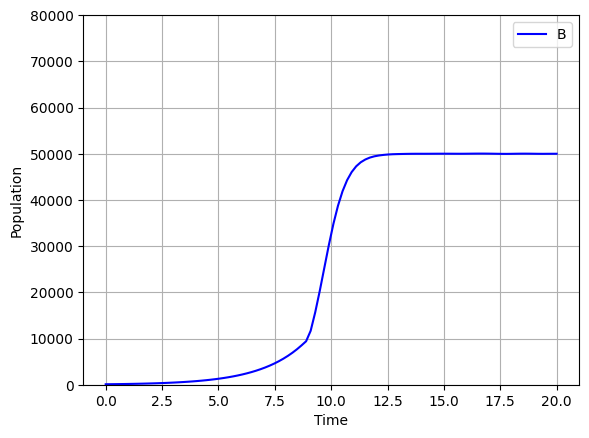

In [39]:
#set up logistic equation for https://www.nature.com/articles/s41564-018-0314-4. 
B = symbols('B')
K =  5e4 #from paper; estimated based on model fit
r = 2 #estimated based on model fit; this a doubling time of 1hr
k = math.log(100)/9 #estimated to create a delay state

def model(t, B):
    if t<9: #9hrs estimated critical population from paper data
        dBdt = k*B #slow exponential growth at first; easier than delay function!
    else:
        dBdt = r*B*(1 - (B/K))
    return [dBdt]

t_span = (0, 20)
initial = [100]

t_evaluate = np.linspace(0, 20, 100)

sol = solve_ivp(fun = model, t_span = t_span, y0 = initial, method = 'RK45', t_eval = t_evaluate)


plt.plot(sol.t, sol.y[0], label='B', color='blue')
plt.xlabel('Time')
plt.ylabel('Population')
plt.ylim(0,8e4)
plt.legend()
plt.grid(True)
plt.show()